<a href="https://colab.research.google.com/github/haaniyaafaheemaa/haaniyaa-codeboosters-2026/blob/main/Day-02/Day_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All Libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All Libraries imported successfully!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows: ")
df.head(3)

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows: 


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)

result = pd.read_sql("SELECT * FROM students LIMIT 5", conn)

print(result)

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [ ]:
def run_query(sql,description="students"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

In [ ]:
query1 = """
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
  LIMIT 10
"""
result1 = run_query(query1,"Query 1:First 10 Students (SELECT + LIMIT)")

Query 1:First 10 Students (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2 = """SELECT name,department,math_score FROM students ORDER BY math_score DESC LIMIT 5 """
result2=run_query(query2,"Top 5 Math Scores")

Top 5 Math Scores
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
query3 = """
SELECT name, math_score, science_score, programming_score, attendance_percentage
FROM students
WHERE department = 'Computer Science'
ORDER BY programming_score DESC
"""
result3 = run_query(query3)

students
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79             84                 83       

In [ ]:
query4 = """
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 93 AND department != 'Mechanical'
ORDER BY attendance_percentage DESC
LIMIT 3
"""
result4 = run_query(query4)

students
       name       department  attendance_percentage
 Ananya Das Computer Science                     98
Tanvi Mehta Computer Science                     97
Divya Singh Computer Science                     96


In [ ]:
query5 = """
SELECT name, department
FROM students
WHERE name BETWEEN 'A' AND 'F'
"""
result5 = run_query(query5)

students
          name       department
  Aarav Sharma Computer Science
    Arjun Nair Computer Science
   Divya Singh Computer Science
    Ananya Das Computer Science
   Ajay Tiwari Computer Science
Deepak Chauhan       Mechanical
     Amit Bose Computer Science
Akanksha Yadav Computer Science


In [ ]:
query6 = """
SELECT department,
COUNT(*),
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result6 = run_query(query6)

students
      department  COUNT(*)  avg_math_score  avg_science_score  avg_programming_score
Computer Science        13           85.62              84.46                  89.23
      Mechanical         6           71.00              76.50                  49.33
     Electronics         6           71.00              74.17                  61.50
           Civil         5           63.40              66.60                  40.60


In [ ]:
query7 = """
SELECT name, department,
COUNT(*),
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result7 = run_query(query7)

students
        name       department  COUNT(*)  avg_math_score  avg_science_score  avg_programming_score
Aarav Sharma Computer Science        13           85.62              84.46                  89.23
 Sneha Reddy       Mechanical         6           71.00              76.50                  49.33
 Rohit Verma      Electronics         6           71.00              74.17                  61.50
 Kiran Kumar            Civil         5           63.40              66.60                  40.60


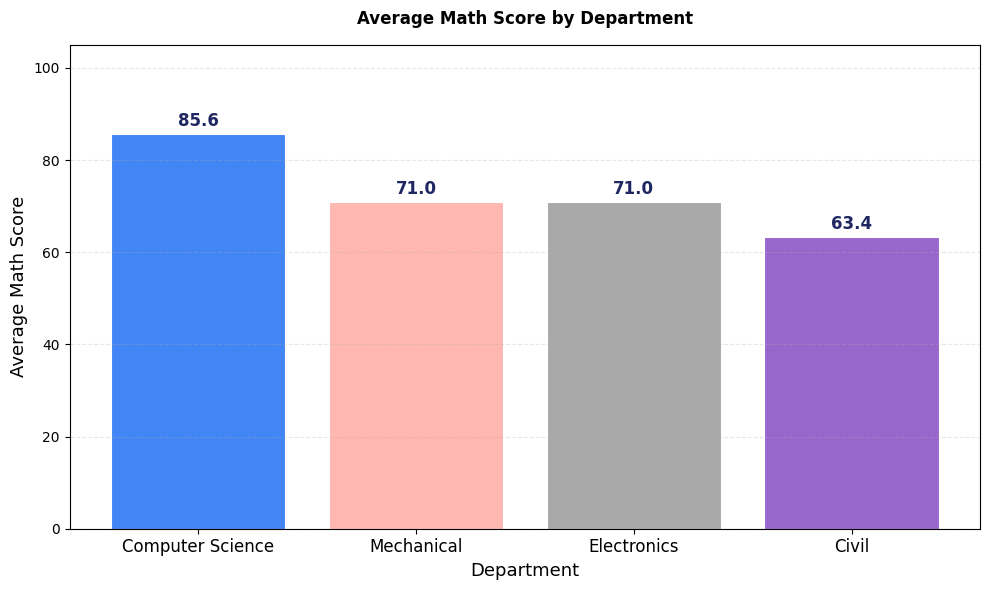

In [ ]:
chart1_sql = """
SELECT department, ROUND(AVG(math_score),2) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
chart1_data =  pd.read_sql_query(chart1_sql,conn)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#4285F4', '#FFB7B2', '#A9A9A9', '#9966CC']
bars = ax.bar(chart1_data['department'],
              chart1_data['avg_math_score'],
              color=bar_colors,
              edgecolor = 'white',
              linewidth = 0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize = 12, fontweight = 'bold',
        color = '#1E2761')

ax.set_xlabel('Department', fontsize = 13)
ax.set_ylabel('Average Math Score', fontsize = 13)
ax.set_title('Average Math Score by Department',fontsize = 12, fontweight = 'bold', pad = 15)
ax.set_ylim(0,105)
ax.tick_params(axis='x', labelsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [67]:
query8 = """
SELECT gender, ROUND(AVG(programming_score),2) AS avg_programming
FROM students
WHERE gender = 'Female'
"""

result8 = run_query(query8)


students
gender  avg_programming
Female             70.2


In [69]:
query9 = """
SELECT department, ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
HAVING avg_attendance > 85
"""
result9 = run_query(query9)

students
      department  avg_attendance
Computer Science           90.69
